# Physics 110A (Regan) — Problem Set #1, Completed

| # | problem | where |
|---|---------|-------|
| 1 | G1.10 pseudovectors | `griffiths_1p10_pseudovectors.ipynb` |
| 2 | G1.13 derivatives of $\mathscr r$ | `griffiths_ch1_solutions.ipynb` §2 |
| 3 | G1.22 $(\mathbf A\cdot\nabla)\mathbf B$ | `griffiths_ch1_solutions.ipynb` §4 |
| 4 | **G1.39 divergence theorem, $f(r)\hat r$** | **§1 below** |
| 5 | G1.45 $\delta$-function practice | `griffiths_ch1_solutions.ipynb` §8 |
| 6 | G1.46 $\delta$ identities | `griffiths_ch1_solutions.ipynb` §9 |
| 7 | **G12.17 invariance of the 4-dot product** | **§2 below** |
| 8 | **G12.19 rapidity** | **§3 below** |
| 9 | **G12.20 practicing Lorentz transformations** | **§4 below** |
| 10 | **G12.30 $E_\text{kin} = n\,mc^2$** | **§5 below** |
| 11 | **Maxwell from $\Box^2 V, \Box^2\mathbf A$** | **§6 below** |

Engine: the repo's `griffiths` package (`relativity.py` and `potentials.py` added for this set).
Conventions are Griffiths': $x^0 = ct$, $\eta = \mathrm{diag}(-1,+1,+1,+1)$,
$I = -(c\,\Delta t)^2 + |\Delta\mathbf r|^2$.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

import griffiths as gr
from griffiths import relativity as rel
from griffiths import potentials as pot

sp.init_printing(use_latex="mathjax")
print("griffiths package", gr.__version__)

griffiths package 0.1.0


## §1 — G1.39: the divergence theorem for radial fields $v = r^n\,\hat r$

In spherical coordinates $\nabla\cdot(r^n\hat r) = \frac{1}{r^2}\frac{d}{dr}(r^{n+2}) = (n+2)\,r^{n-1}$.
Both sides of the divergence theorem give $4\pi R^{n+2}$ over a sphere of radius $R$ — *until*
$n = -2$, where the naive volume integral collapses to zero but the flux stubbornly stays $4\pi$.
That mismatch is the $\delta^3$ of §2 in `gradcurldiv_jalali_robotics.ipynb`, now caught red-handed
by the divergence theorem itself.

In [2]:
R = sp.Symbol("R", positive=True)
rows = []
for n in (2, 1, 0, -2):
    d, vol, surf = gr.radial_div_theorem(n, R)
    rows.append((n, d, vol, surf))
    display(Math(rf"n={n}:\quad \nabla\cdot(r^{{{n}}}\hat r) = " + sp.latex(d)
                 + r",\qquad \int(\nabla\cdot v)\,d\tau = " + sp.latex(vol)
                 + r",\qquad \oint v\cdot d\mathbf a = " + sp.latex(surf)
                 + (r"\quad\checkmark" if sp.simplify(vol - surf) == 0
                    else r"\quad\Leftarrow\ \text{the }\delta^3\text{ case!}")))

display(Math(r"n=-2:\ \text{divergence theorem rescued only by }"
             r"\nabla\cdot(\hat r/r^2) = 4\pi\,\delta^3(\mathbf r)"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §2 — G12.17: the scalar product $a\cdot b = -a^0b^0 + \mathbf a\cdot\mathbf b$ is Lorentz invariant

Strategy (same as G1.8 for rotations): invariance of $a^T\eta\,b$ under $a\to\Lambda a$ holds iff
$\Lambda^T\eta\,\Lambda = \eta$. For rotations the statement was $R^TR = \mathbb 1$ — same theorem,
different quadratic form. Euclidean geometry preserves $x^2+y^2+z^2$; spacetime geometry preserves
$-(ct)^2+x^2+y^2+z^2$. The boost *is* a rotation, just through an imaginary angle.

In [3]:
beta = sp.Symbol("beta", real=True)
L = rel.boost(beta)
display(Math(r"\Lambda = " + sp.latex(L)))
check = sp.simplify(L.T * rel.ETA * L)
display(Math(r"\Lambda^T\eta\,\Lambda = " + sp.latex(check) + r" = \eta\quad\checkmark"))
assert rel.is_lorentz(L)

# hence for ANY two 4-vectors (symbolic components):
a = sp.Matrix(sp.symbols("a0:4", real=True))
b = sp.Matrix(sp.symbols("b0:4", real=True))
before = rel.minkowski(a, b)
after = rel.minkowski(L * a, L * b)
display(Math(r"(\Lambda a)\cdot(\Lambda b) - a\cdot b = "
             + sp.latex(sp.simplify(after - before))))

# the G1.8 comparison: rotations preserve the Euclidean form the same way
phi = sp.Symbol("phi", real=True)
Rm = rel.rotation2(phi)
display(Math(r"R^T R = " + sp.latex(sp.simplify(Rm.T * Rm))
             + r"\quad\text{(G1.8: same theorem, metric } \mathbb 1 \text{ instead of } \eta)"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §3 — G12.19: rapidity $\theta \equiv \tanh^{-1}(v/c)$

**(a)** With $\cosh\theta = \gamma$ and $\sinh\theta = \gamma\beta$, the boost becomes the
hyperbolic twin of the rotation matrix (Eq. 1.29):

$$\Lambda = \begin{pmatrix}\cosh\theta & -\sinh\theta\\ -\sinh\theta & \cosh\theta\end{pmatrix}
\qquad\text{vs.}\qquad
R = \begin{pmatrix}\cos\phi & \sin\phi\\ -\sin\phi & \cos\phi\end{pmatrix}$$

**(b)** Because $\Lambda(\theta_1)\Lambda(\theta_2) = \Lambda(\theta_1+\theta_2)$, rapidities simply
**add** — and the Einstein velocity addition law is nothing but the $\tanh$ sum identity.

In [4]:
theta, t1, t2 = sp.symbols("theta theta_1 theta_2", real=True)

display(Math(r"\Lambda(\theta) = " + sp.latex(rel.boost2(theta))
             + r",\qquad R(\phi) = " + sp.latex(rel.rotation2(sp.Symbol("phi")))))

# gamma = cosh(theta), gamma*beta = sinh(theta) -- check against atanh(beta):
b = sp.Symbol("beta", positive=True)
L_beta = rel.boost(b)[0:2, 0:2]
L_theta = rel.boost_rapidity(sp.atanh(b))[0:2, 0:2].applyfunc(lambda e: e.rewrite(sp.sqrt))
assert sp.simplify(L_beta - L_theta) == sp.zeros(2, 2)
print("Lambda(beta) == Lambda(theta = atanh beta)  [gamma=cosh, gamma beta=sinh]")

# rapidities add:
prod = sp.simplify(rel.boost2(t1) * rel.boost2(t2))
display(Math(r"\Lambda(\theta_1)\Lambda(\theta_2) = " + sp.latex(prod)
             + r" = \Lambda(\theta_1+\theta_2)\quad\checkmark"))
assert sp.simplify(prod - rel.boost2(t1 + t2)) == sp.zeros(2, 2)

<IPython.core.display.Math object>

Lambda(beta) == Lambda(theta = atanh beta)  [gamma=cosh, gamma beta=sinh]


<IPython.core.display.Math object>

<IPython.core.display.Math object>

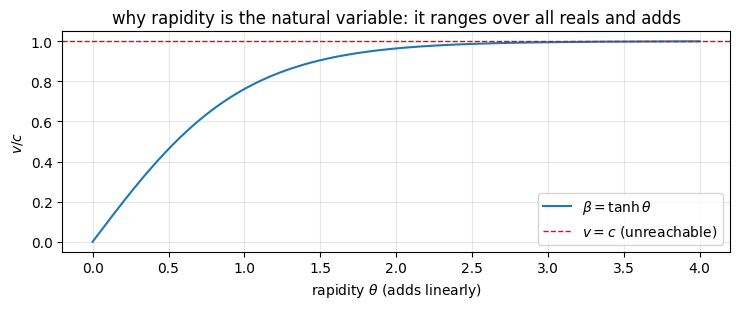

In [5]:
# (b) Einstein addition in rapidity language
u = rel.add_velocities(sp.tanh(t1), sp.tanh(t2))
display(Math(r"\frac{u'+v}{1+u'v/c^2}\Big/c = \frac{\tanh\theta_1+\tanh\theta_2}"
             r"{1+\tanh\theta_1\tanh\theta_2} = " + sp.latex(sp.simplify(u))
             + r"\;=\;\tanh(\theta_1+\theta_2)"))
assert sp.simplify(u - sp.tanh(t1 + t2)) == 0

# velocities saturate at c; rapidities just keep adding
ths = np.linspace(0, 4, 400)
plt.figure(figsize=(7.5, 3.2))
plt.plot(ths, np.tanh(ths), label=r"$\beta = \tanh\theta$")
plt.axhline(1, color="r", ls="--", lw=1, label=r"$v=c$ (unreachable)")
plt.xlabel(r"rapidity $\theta$ (adds linearly)"); plt.ylabel(r"$v/c$")
plt.title("why rapidity is the natural variable: it ranges over all reals and adds")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## §4 — G12.20: practicing the Lorentz transformation

Event $A$: $(x_A, y_A, z_A) = (5, 3, 0)$ at $ct_A = 15$; event $B$: $(10, 8, 0)$ at $ct_B = 5$
(both in system $\mathcal S$, units where lengths are in the same units as $ct$).

In [6]:
A = (15, 5, 3, 0)        # (ct, x, y, z)
B = (5, 10, 8, 0)

# (i) invariant interval
I = rel.interval(A, B)
kind = rel.classify_interval(I)
display(Math(r"(i)\quad I = -(c\Delta t)^2 + |\Delta\mathbf r|^2 = -(-10)^2 + (5^2+5^2) = "
             + sp.latex(I) + rf"\quad\Rightarrow\ \textbf{{{kind}}}"))

# (ii) simultaneity would need a spacelike interval
print(f"(ii) simultaneous frame? interval is {kind} (I<0) -> NO frame exists;")
print("     simultaneity requires spacelike separation (I>0).")

# (iii) timelike -> a frame DOES exist where they co-locate
v = rel.connecting_velocity(A, B)
speed = sp.sqrt(sum(c**2 for c in v))
display(Math(r"(iii)\quad \boldsymbol\beta = \frac{\mathbf r_B-\mathbf r_A}{c(t_B-t_A)} = "
             + sp.latex(v.T) + r",\qquad |\mathbf v| = " + sp.latex(speed)
             + r"\,c \approx 0.707c"))
print("     direction: -(x+y)/sqrt(2) -- B happens BEFORE A (ct_B < ct_A), so the")
print("     frame chases from B's location back toward A's.")

# sanity: boost along that beta really does co-locate the events (rotate axes so beta || x)
d = sp.Matrix(B) - sp.Matrix(A)
d_rot = sp.Matrix([d[0], -sp.sqrt(d[1]**2 + d[2]**2), 0, 0])   # x-axis along -(1,1,0)/sqrt2
moved = (rel.boost(sp.sqrt(2)/2) * d_rot).applyfunc(sp.simplify)
display(Math(r"\Lambda(\beta{=}\tfrac{\sqrt2}{2})\,\Delta x^\mu = " + sp.latex(moved.T)
             + r"\quad\text{(spatial part } = 0\text{: same point, time apart } \sqrt{50}/c)"))

<IPython.core.display.Math object>

(ii) simultaneous frame? interval is timelike (I<0) -> NO frame exists;
     simultaneity requires spacelike separation (I>0).


<IPython.core.display.Math object>

     direction: -(x+y)/sqrt(2) -- B happens BEFORE A (ct_B < ct_A), so the
     frame chases from B's location back toward A's.


<IPython.core.display.Math object>

## §5 — G12.30: kinetic energy $= n\times$ rest energy

$E_\text{kin} = (\gamma - 1)mc^2 = n\,mc^2 \Rightarrow \gamma = n+1$, so

$$v = c\sqrt{1 - \frac{1}{(n+1)^2}} = \frac{c\,\sqrt{n(n+2)}}{n+1}$$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

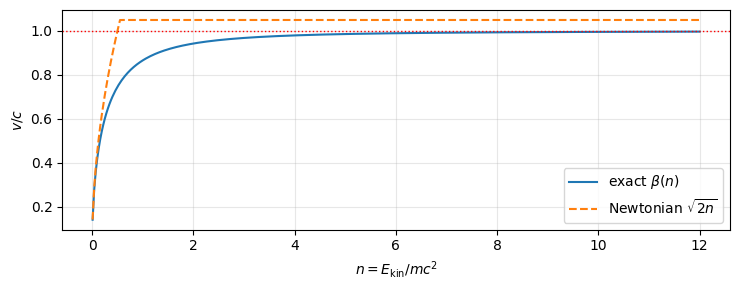

In [7]:
n = sp.Symbol("n", positive=True)
beta_n = rel.speed_from_kinetic_ratio(n)
display(Math(r"\beta(n) = " + sp.latex(beta_n)
             + r" = \frac{\sqrt{n(n+2)}}{n+1}"))

for val in [sp.Rational(1, 2), 1, 2, 10]:
    bv = rel.speed_from_kinetic_ratio(val)
    display(Math(rf"n = {sp.latex(sp.sympify(val))}:\quad \beta = " + sp.latex(bv)
                 + rf" \approx {float(bv):.4f}"))

# limits: Newtonian (n->0: beta ~ sqrt(2n)) and ultrarelativistic (n->oo: beta->1)
display(Math(r"n\to 0:\ \beta \to " + sp.latex(sp.limit(beta_n / sp.sqrt(2*n), n, 0))
             + r"\cdot\sqrt{2n}\ \text{(i.e. } \tfrac12 mv^2 = n\,mc^2\text{)}"
             + r",\qquad n\to\infty:\ \beta\to " + sp.latex(sp.limit(beta_n, n, sp.oo))))

ns = np.linspace(0.01, 12, 400)
plt.figure(figsize=(7.5, 3))
plt.plot(ns, np.sqrt(ns*(ns+2))/(ns+1), label=r"exact $\beta(n)$")
plt.plot(ns, np.minimum(np.sqrt(2*ns), 1.05), "--", label=r"Newtonian $\sqrt{2n}$")
plt.axhline(1, color="r", lw=1, ls=":")
plt.xlabel(r"$n = E_{\rm kin}/mc^2$"); plt.ylabel(r"$v/c$")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## §6 — Problem 11: Maxwell's equations *from* the wave equations

**Given** (Eqs. 10.16, equivalently 12.137), with $\Box^2 \equiv \nabla^2 - \mu_0\epsilon_0\,\partial_t^2$:

$$\text{(i)}\ \Box^2 V = -\frac{\rho}{\epsilon_0},\qquad \text{(ii)}\ \Box^2\mathbf A = -\mu_0\mathbf J,
\qquad\text{Lorenz gauge: } \nabla\cdot\mathbf A = -\mu_0\epsilon_0\frac{\partial V}{\partial t}$$

**and the definitions** (Eqs. 10.2–10.3): $\mathbf B = \nabla\times\mathbf A$,
$\ \mathbf E = -\nabla V - \partial_t\mathbf A$. **Derive Eqs. 10.1** — all four Maxwell equations.

The logic, run for completely generic $V, \mathbf A, \rho, \mathbf J$:
- two Maxwell equations are *identities* of the definitions (the homogeneous pair),
- the other two are *exactly* the wave equations, once the Lorenz gauge eliminates the cross terms.

In [8]:
V, A = pot.generic_potentials()
rho, J = pot.generic_sources()
eps0 = sp.Symbol("epsilon_0", positive=True)
c, t = pot.c, pot.t
mu0 = 1 / (eps0 * c**2)               # mu0 eps0 = 1/c^2

E = pot.E_from_potentials(V, A)       # Eq. 10.3
B = pot.B_from_potentials(A)          # Eq. 10.2
G = pot.lorenz_gauge_residual(V, A)   # = 0 in Lorenz gauge
WV = pot.dalembertian(V) + rho/eps0   # = 0 is wave equation (i)
WA = sp.Matrix([pot.dalembertian(A[i]) for i in range(3)]) + mu0*J  # (ii)

# --- the two identities (no gauge, no wave equation needed) ---
divB = sp.simplify(gr.div(B))
faraday = sp.simplify(gr.curl(E) + sp.diff(B, t))
display(Math(r"\nabla\cdot\mathbf B = \nabla\cdot(\nabla\times\mathbf A) = "
             + sp.latex(divB) + r"\quad\checkmark\ \text{(10.1 ii)}"))
display(Math(r"\nabla\times\mathbf E + \frac{\partial\mathbf B}{\partial t} = "
             r"-\nabla\times\nabla V = " + sp.latex(faraday.T)
             + r"\quad\checkmark\ \text{(10.1 iii)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
# --- Gauss's law: div E - rho/eps0  ==  -(wave eq i) - d/dt(gauge) ---
gauss_residual = gr.div(E) - rho/eps0
identity1 = sp.simplify(gauss_residual - (-WV - sp.diff(G, t)))
display(Math(r"\nabla\cdot\mathbf E - \frac{\rho}{\epsilon_0} \;=\; "
             r"-\Bigl(\Box^2 V + \tfrac{\rho}{\epsilon_0}\Bigr)"
             r" - \frac{\partial}{\partial t}\Bigl(\nabla\cdot\mathbf A"
             r" + \tfrac{1}{c^2}\partial_t V\Bigr)"
             + r"\qquad\text{[algebraic identity: residual } = "
             + sp.latex(identity1) + r"\text{]}"))
assert identity1 == 0
display(Math(r"\text{wave eq (i)} = 0,\ \text{gauge} = 0\ \Rightarrow\ "
             r"\boxed{\nabla\cdot\mathbf E = \rho/\epsilon_0}\ \text{(10.1 i)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# --- Ampere-Maxwell: curl B - mu0 J - mu0 eps0 dE/dt  ==  -(wave eq ii) + grad(gauge) ---
ampere_residual = gr.curl(B) - mu0*J - sp.diff(E, t)/c**2
identity2 = sp.simplify(sp.expand(ampere_residual - (-WA + gr.grad(G))))
display(Math(r"\nabla\times\mathbf B - \mu_0\mathbf J - \mu_0\epsilon_0\frac{\partial\mathbf E}{\partial t}"
             r" \;=\; -\bigl(\Box^2\mathbf A + \mu_0\mathbf J\bigr) + \nabla\Bigl(\nabla\cdot\mathbf A"
             r" + \tfrac{1}{c^2}\partial_t V\Bigr)"
             + r"\qquad\text{[residual } = " + sp.latex(identity2.T) + r"\text{]}"))
assert identity2 == sp.zeros(3, 1)
display(Math(r"\text{wave eq (ii)} = 0,\ \text{gauge} = 0\ \Rightarrow\ "
             r"\boxed{\nabla\times\mathbf B = \mu_0\mathbf J"
             r" + \mu_0\epsilon_0\,\partial_t\mathbf E}\ \text{(10.1 iv)}"))
print("All four Maxwell equations recovered from the wave equations + Lorenz gauge,")
print("with V, A, rho, J fully generic. (curl B - mu0 eps0 dE/dt uses grad(div A)")
print("- del^2 A = curl curl A, which the residual algebra carries automatically.)")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

All four Maxwell equations recovered from the wave equations + Lorenz gauge,
with V, A, rho, J fully generic. (curl B - mu0 eps0 dE/dt uses grad(div A)
- del^2 A = curl curl A, which the residual algebra carries automatically.)


: 

**Moral (Regan's point):** in the Lorenz gauge, *electrodynamics = the inhomogeneous wave
equation*. Maxwell's equations and "$\Box^2(\text{potentials}) = -(\text{sources})$" are the same
physics packaged differently — which is why the d'Alembertian is the Laplacian's 4-D upgrade and
why dispersion engineering (this repo's bread and butter) is just wave-equation engineering.

**Where this lands in the repo:** Lorentz invariance of the 4-dot product is the symmetry behind
the dispersion relation $\omega^2/c^2 - k^2$ conserved along the fiber in `gs_core.py`; rapidity
adding like a phase is the same trick as cascading dispersive stages (D parameters add); and
turbines/EM covariant formulation continues in `turbines_em_covariant_tsdft_vocal.ipynb`.